In [112]:
import numpy as np
import torch
import torch.nn as nn
import time

from scipy.integrate import solve_ivp as sp_solve_ivp
from tqdm.auto import tqdm
from ftnode.utils import set_global_seed
from sklearn.preprocessing import MinMaxScaler
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,
     GeluSigmoidMLPfeaturized
)
from typing import List
from scipy.optimize import root_scalar

import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family']= 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed,deterministic=True)
# random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [113]:
def budworm_ode(t,x,r,k):
    return r*x*(1-x/k) - x**2 / (1+x**2)

from sympy import symbols, Eq, solve, simplify
r, k = symbols('r k', positive=True)
a = r/k
b = -r
c = (k+r)/k
d = -r
p = (3*a*c-b**2) / (3*a**2)
q = (2*b**3 - 9*a*b*c+27*a**2*d) / (27*a**3)

D = - (4*p**3 + 27*q**2)
D = simplify(D)


D_fixed = D.subs(r, 0.56)
r1, r2 = solve(Eq(D_fixed, 0), k)
print(r1,r2)

6.44569072482332 9.93441120446710


In [114]:
n_control = 51
n_traj = 51

r=0.56
us = np.linspace(float(r1)-2,float(r2)+2, n_control)
xs = np.linspace(0.1,10, n_traj)

In [115]:
t_max = 10
n_colloc = 801

x_trials = []
t_trials = []
u_trials = []

for ui in tqdm(us):
    for x0 in xs:
        sol = sp_solve_ivp(
            budworm_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (r,ui,)
        )

        x_trials.append(sol.y.T)
        t_trials.append(sol.t.reshape(-1,1))
        u_trials.append(ui)
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(np.array(x_trials).reshape(-1,1))

  0%|          | 0/51 [00:00<?, ?it/s]

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [116]:
model_path = "../best_model-20-20.pth"

f = FeluSigmoidMLP(
    dims=[1, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-1,
    upper_bound=-0.1,
)

g = GeluSigmoidMLPfeaturized(
    dims=[6, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1,
    feat_upper_bound=1.5,
)

model = FTNODE(f, g)
model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()


GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1): Linear(in_features=20, out_features=20, bias=True)
      (2): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

In [117]:
def R(u,x,k, x_target):
    for _ in range(k):
        x = g(x, u)
    return x - x_target

def u_prime(u,x,x_target,eta,k):
    u = torch.tensor(u,dtype=torch.float32, requires_grad=True)
    x = torch.tensor(x,dtype=torch.float32, requires_grad=False)
    x_target = torch.tensor(x_target,dtype=torch.float32, requires_grad=False)
    resid = torch.sum(R(u,x,k,x_target)**2)
    resid.backward()

    grad = u.grad.numpy()
    return -eta*grad

def budworm_ode_control(t,xu,x_target,eta,k):
    x = xu[:1]
    u = xu[1:]
    x_scaled = scaler.transform(x.reshape(-1,1)).reshape(-1)
    x_target_scaled = scaler.transform(x_target.reshape(-1,1)).reshape(-1)

    dxdt = budworm_ode(t,x,r,u)
    dudt = u_prime(u,x_scaled,x_target_scaled, eta,k)

    return np.hstack([dxdt,dudt])


def make_drift(x_target, scaler, eta, k):
    """
    Drift for SDE: d[x,u]^T = drift(x,u,t)*dt + diffusion(x,u,t)*dW
    """

    def drift(xu, t):
        x = xu[0]
        u = xu[1]


        x_scaled = scaler.transform(np.array([[x]]))
        x_target_scaled = scaler.transform(np.array([[x_target]]))
        

        # dxdt = hysteresis_ode(t, x, u)
        dxdt = budworm_ode(t, x,0.56 ,u)
        u = np.array([[u]])

        dudt = u_prime(u, x_scaled, x_target_scaled, eta, k)[0,0]

        return np.array([dxdt, dudt])

    return drift

def scalar_noise(x, scale=0.01):
    """
    Example multiplicative noise for scalar system.
    """
    sig = scale * np.sqrt(abs(x))
    return sig

def make_diffusion(scale):
    """
    Diffusion matrix G(x) for SDE:
        d[x,u]^T = drift dt + G dW
    G : (2 × 1) matrix in scalar case
    """

    def diffusion(xu, t):
        x = xu[0]
        sig = scalar_noise(x, scale)

        G = np.zeros((2, 1))
        G[0, 0] = sig   
        return G

    return diffusion



In [118]:
seed = 67
rng = np.random.default_rng(seed=seed)

n_targets = 10

x_targets = []
for idx in range(n_targets):
    x_targets.append(rng.uniform(0.1,10))

In [119]:
t_max = 100
n_colloc = 501
eta = 5e1
k = 1

xu0 = np.array([5,7])



Ts = []
Xs = []
Us = []
Xs_targets = []

for x_target in tqdm(x_targets):
    x_target = np.array(x_target)
    sol = sp_solve_ivp(
        budworm_ode_control,
        t_span = [0,t_max],
        y0 = xu0,
        t_eval = np.linspace(0,t_max, n_colloc),
        args = (x_target,eta,k)
    )

    XU = sol.y
    X = XU[0,:]
    U = XU[1,:]
    xu0 = sol.y[:,-1]

    Ts.append(sol.t)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)

  0%|          | 0/10 [00:00<?, ?it/s]

In [120]:
Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    xi=Xs[i]
    
    xi_scaled_tensor = torch.tensor(scaler.transform(xi.reshape(-1,1)),dtype=torch.float32)
    ui_tensor = torch.tensor(ui.reshape(-1,1), dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_scaled_tensor, ui_tensor)
    
    gi_unscaled = scaler.inverse_transform(gi).reshape(-1)
    Gs.append(gi_unscaled)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)

  0%|          | 0/10 [00:00<?, ?it/s]

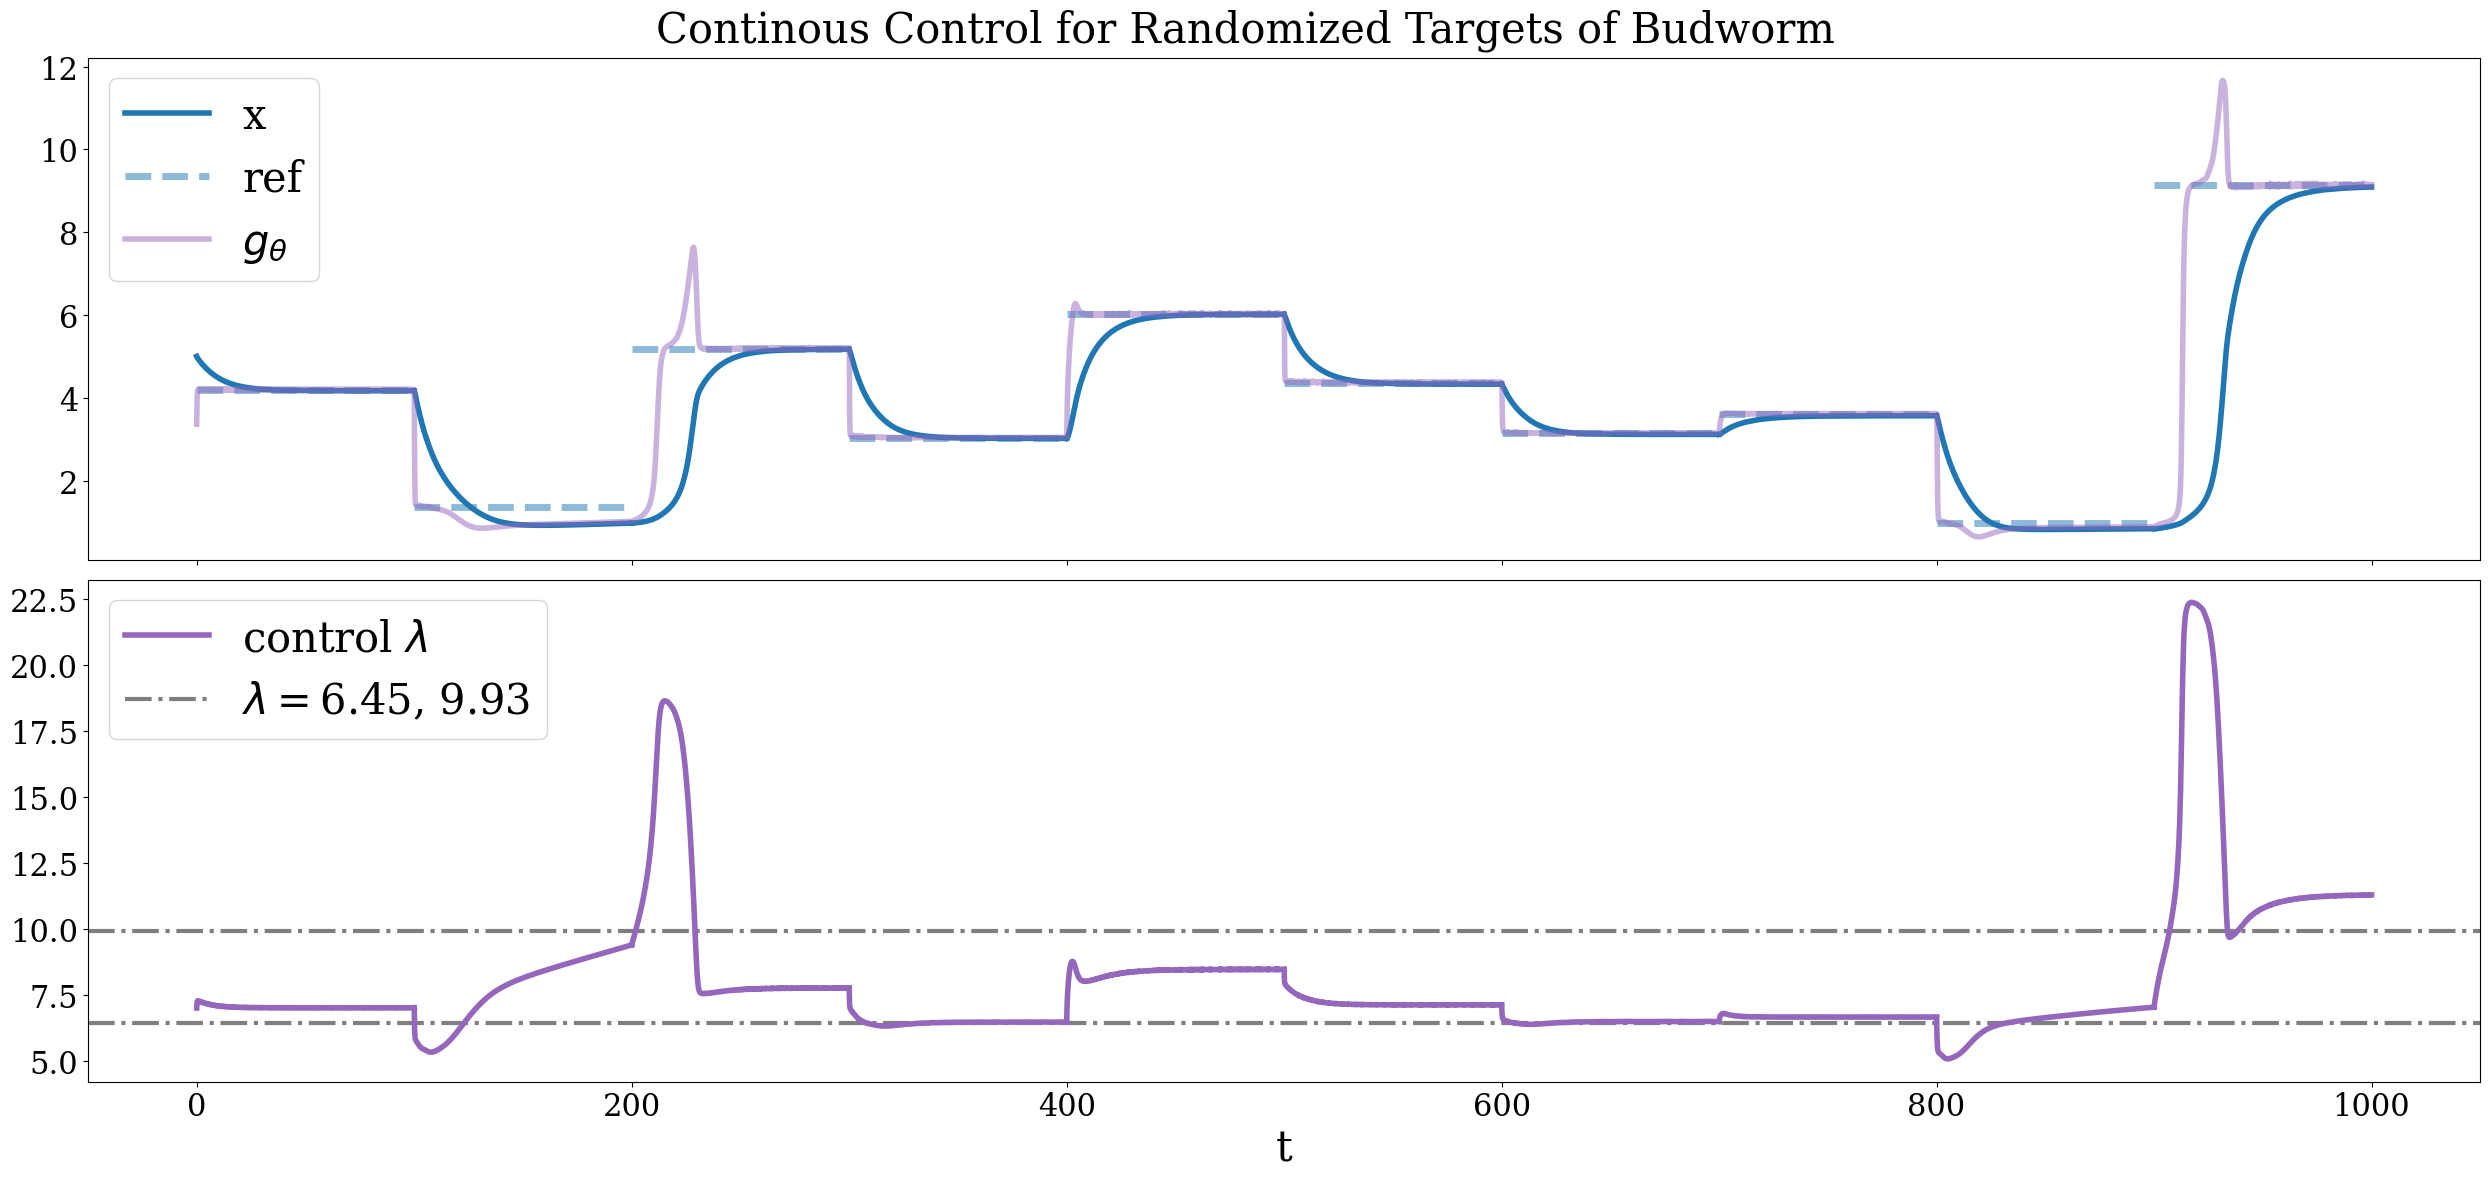

In [121]:
lw=4


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(2.5*n_targets, 12),sharex=True)

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]
    Gsi = Gs[idx]

    tank1_label = None
    tank2_label = None

    tar1_label = None
    tar2_label = None

    g_label = None

    if idx == 0:
        tank1_label = "x"
        tank2_label = "Tank 2"

        tar1_label="ref"
        tar2_label="ref 2"
        g_label = r"$g_\theta$"


    ax1.plot(ti, Xsi,c='tab:blue',lw=lw,label=tank1_label)
    # ax1.plot(ti,Gsi,c='tab:purple',lw=lw,label = g_label,alpha=0.5)
    # ax1.plot(ti, Xsi[1,:],c='tab:red',lw=lw,label=tank2_label)
    ax1.hlines(
        Xsi_target,
        xmin=ti[0],
        xmax=ti[-1],
        color='tab:blue',
        linestyle='--',
        alpha=0.5,
        lw=lw+1,
        label=tar1_label
        )


    

    p_label=None
    v_label = None
    if idx ==0:
        p_label = r"control $\lambda$"
        v_label = "Valve Opening"


    ax2.plot(ti,Usi,c='tab:purple',lw=lw,label=p_label)

    ax2.set_xlabel("t",size=30)

    

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=18)

ax1.plot(T_tot,G_tot,c='tab:purple',lw=lw,label = r"$g_\theta$",alpha=0.5)
ax1.legend(fontsize=30)

ax2.axhline(float(r2),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=3,label=rf"$\lambda =${float(r1):.2f}, {float(r2):.2f}")
ax2.axhline(float(r1),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=3)
ax2.legend(fontsize=30)

plt.suptitle(
    "Continous Control for Randomized Targets of Budworm"  
    ,size=30)
plt.tight_layout()
plt.show()

# Stochastic Targets

In [122]:
def itoint(drift_func, diff_func, y0, t_span, dW):
    """
    A simple Euler-Maruyama solver that accepts pre-generated noise.
    
    Args:
        drift_func: Function f(y, t) returning (d,)
        diff_func:  Function G(y, t) returning (d, m)
        y0:         Initial state (d,)
        t_span:     Time array (N,)
        dW:         Pre-calculated noise increments (N-1, m)
    
    Returns:
        Solution array of shape (N, d)
    """
    N = len(t_span)
    d = len(y0)
    
    # Pre-allocate solution array
    ys = np.zeros((N, d))
    ys[0] = y0
    
    curr_y = y0.copy()
    
    for i in range(N - 1):
        t = t_span[i]
        dt = t_span[i+1] - t
        
        # Get the specific noise increment for this step
        dw_step = dW[i]  # Shape (2,)
        
        # Evaluate dynamics
        f = drift_func(curr_y, t)   # Shape (6,)
        G = diff_func(curr_y, t)    # Shape (6, 2)
        
        # Euler-Maruyama Step: y += f*dt + G*dW
        # matrix multiplication: (6,2) @ (2,) -> (6,)
        diffusion_step = G @ dw_step 
        
        curr_y = curr_y + f * dt + diffusion_step
        # curr_y[:2] = np.maximum(curr_y[:2], 0)
        ys[i+1] = curr_y
        
    return ys

In [123]:
seed = 4
# seed = 11
# seed=29
np.random.seed(seed)
rng = np.random.default_rng(seed=seed)

torch.manual_seed(seed)

torch.use_deterministic_algorithms(True)



n_targets = 10


x_targets = []
for idx in range(n_targets):
    x_targets.append(rng.uniform(0.1,10))


t_max = 100
n_colloc = 501
eta=2e1
k=1
scale = 0.02

t_span = np.linspace(0,t_max, n_colloc)
dt = t_span[1] - t_span[0]


xu0 = np.array([5,7])


Ts = []
Xs = []
Us = []
Xs_targets = []


noise_rng = np.random.default_rng(seed=seed)

for x_target in tqdm(x_targets):
    drift_term = make_drift(x_target,scaler,eta,k)
    diffusion_term = make_diffusion(scale)
    dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 1))

    sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
    X = sto_sol[:,0]
    U = sto_sol[:,1]
    xu0 = sto_sol[-1]

    Ts.append(t_span)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)

Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    xi=Xs[i]
    
    xi_scaled_tensor = torch.tensor(scaler.transform(xi.reshape(-1,1)),dtype=torch.float32)
    ui_tensor = torch.tensor(ui.reshape(-1,1), dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_scaled_tensor, ui_tensor)
    
    gi_unscaled = scaler.inverse_transform(gi).reshape(-1)
    Gs.append(gi_unscaled)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

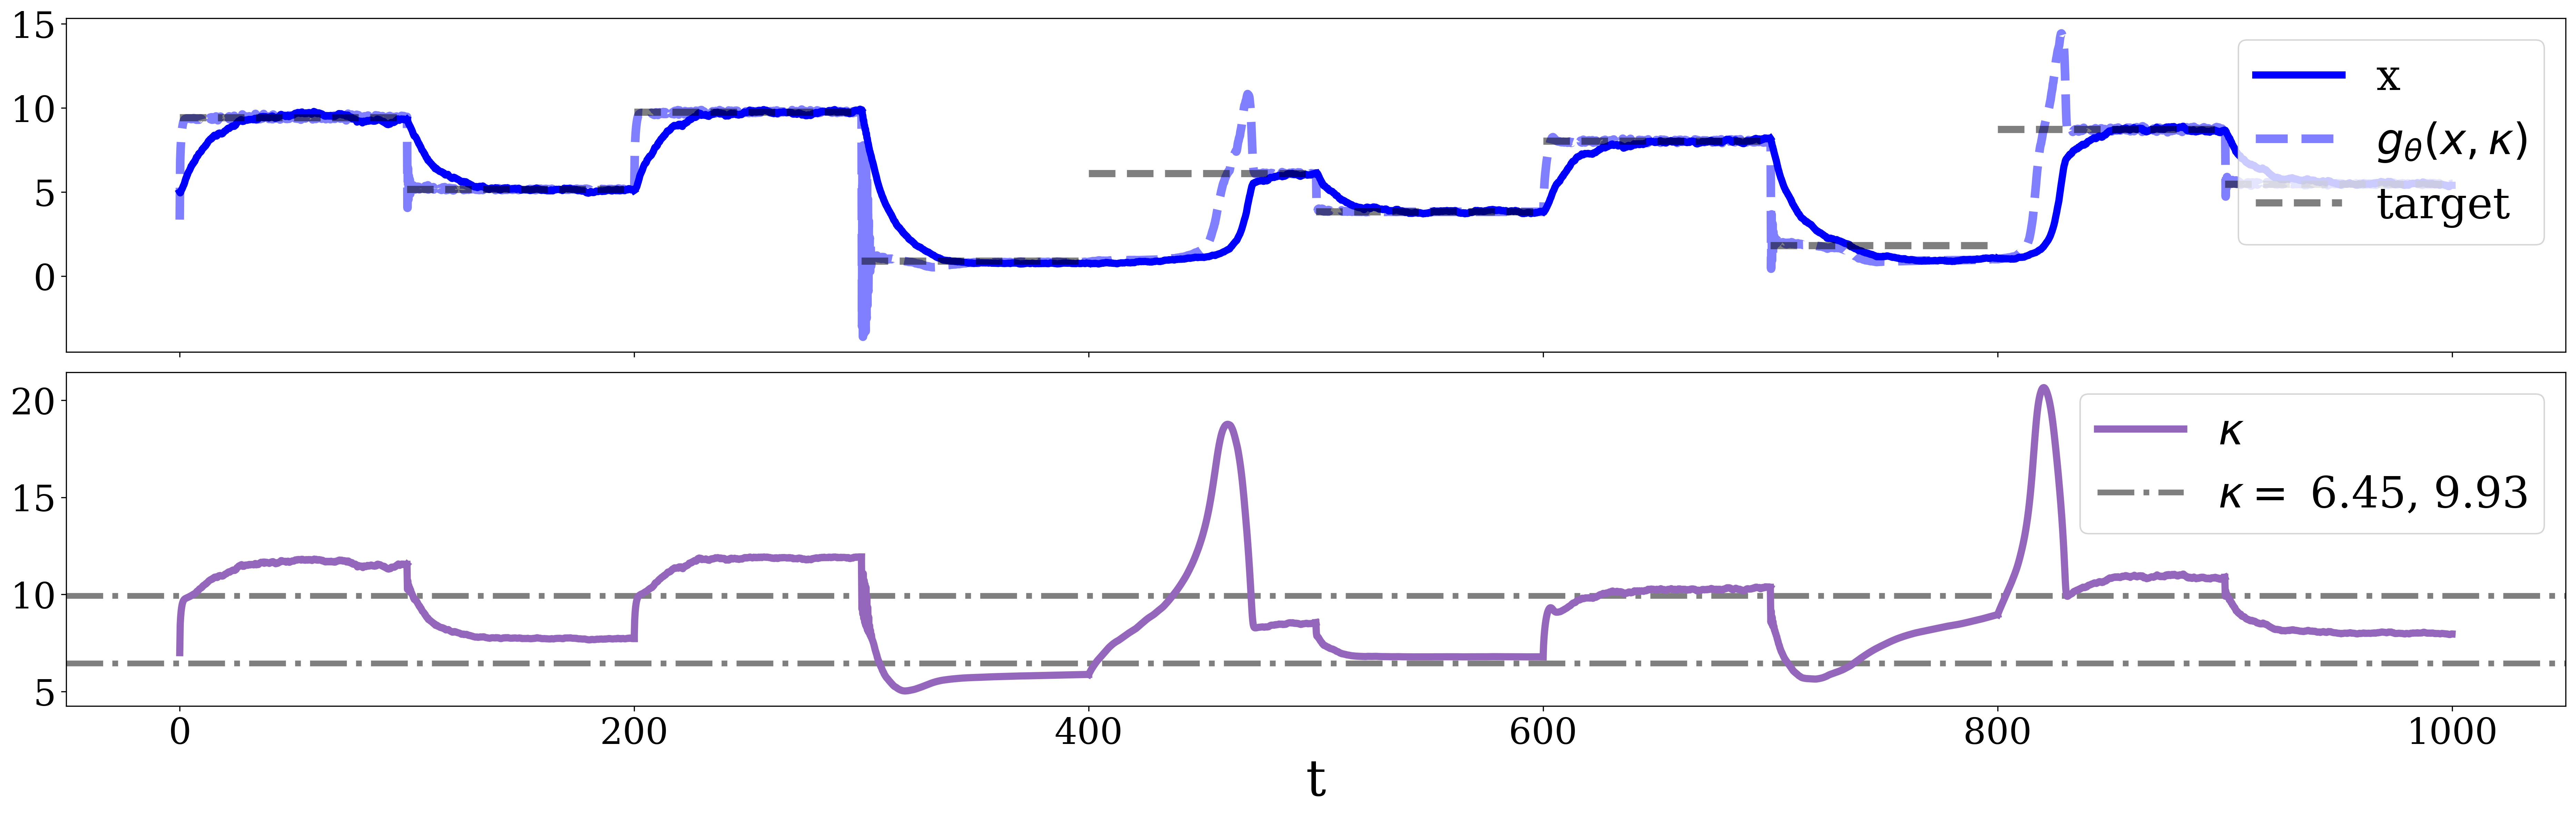

In [127]:
# Ts = [tspan for i in range(n_targets)]
lw=4

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(25, 8),sharex=True,dpi=300)

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]
    Gsi = Gs[idx]

    tank1_label = None
    tank2_label = None

    tar1_label = None
    tar2_label = None

    g_label = None

    if idx == 0:
        tank1_label = "x"
        tank2_label = "Tank 2"

        tar1_label="target"
        tar2_label="ref 2"
        g_label = r"$g_\theta(x,y)$"


    ax1.plot(ti, Xsi,c='blue',lw=lw+1,label=tank1_label)



    

    p_label=None
    v_label = None
    if idx ==0:
        p_label = r"$\kappa$"
        v_label = "Valve Opening"


    ax2.plot(ti,Usi,c='tab:purple',lw=lw+1,label=p_label)

    ax2.set_xlabel("t",size=35)

    # ax2.legend(fontsize=30)

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=25)
    # ax.set_yticks([-2,-1,0,1,2])
    # ax.tick_params(axis='both', which='minor', labelsize=20)

ax1.plot(T_tot,G_tot,c='blue',linestyle='--',lw=lw+2,label = r"$g_\theta(x,\kappa)$",alpha=0.5)
ax2.axhline(float(r1),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=4,label=rf"$\kappa = $ {float(r1):.2f}, {float(r2):.2f}")
ax2.axhline(float(r2),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=4)

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Xsi_target = Xs_targets[idx]

    label=None
    if idx ==0:
        label = r"target"
    ax1.hlines(
        Xsi_target,
        xmin=ti[0],
        xmax=ti[-1],
        color='black',
        linestyle='--',
        alpha=0.5,
        lw=lw+1,
        label=label
        )

ax1.legend(fontsize=30,ncols=1,loc ="upper right")
ax2.legend(fontsize=30,ncols=1,loc ="upper right")
plt.tight_layout()
plt.savefig("budworm-feedback-control.png")
plt.show()

# Multiple Seed Experiment

In [14]:
Xs = []
Xs_targets = []
errs = []
vars = []
stds = []

settling_ratio = 0.2 # Look at last 20% of the trajectory
n_colloc = 501
t_max = 100
eta=2e1
k=1
t_span = np.linspace(0,t_max,n_colloc)
scale = 0.02
dt = t_span[1]-t_span[0]


# t = np.linspace(0,1000,501)
seeds = [i for i in range(100)]

for seed in tqdm(seeds,unit="trial"):
    # print("Seed:", seed)
    rng = np.random.default_rng(seed)
    noise_rng = np.random.default_rng(seed)
    xu0 = np.array([5,7])


    for idx in range(n_targets,):
        # print("case:", idx)
        x_target = np.array(rng.uniform(0.1,10))
        
        drift_term = make_drift(x_target,scaler,eta,k)
        diffusion_term = make_diffusion(scale)
        dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 1))

        sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
        X = sto_sol[:,0]
        U = sto_sol[:,1]
        xu0 = sto_sol[-1]

        # Ts.append(t_span)
        Xs.append(X)
        # Us.append(U)
        Xs_targets.append(x_target)

        # get error and var
        n_steps = len(X)
        start_idx = int(n_steps * (1 - settling_ratio))
        steady_state = X[start_idx:]

        diff = np.abs(steady_state - x_target)
        err = np.linalg.norm(diff, axis=0) / np.sqrt(len(steady_state))
        var = np.var(diff,axis=0)
        stds.append(np.std(steady_state,axis=0))

        errs.append(err)
        vars.append(var)
        
    print(f"running mean: {np.mean(errs)}")

errs = np.array(errs)
vars = np.array(vars)
stds = np.array(stds)
Xs_targets = np.array(Xs_targets)

  0%|          | 0/100 [00:00<?, ?trial/s]

running mean: 0.1768771369277852
running mean: 0.17483580249776876
running mean: 0.21234881815660295
running mean: 0.27123652035346824
running mean: 0.2531674372678724
running mean: 0.2564574211860132
running mean: 0.2388299946117236
running mean: 0.2273266660451177
running mean: 0.2163400205669238
running mean: 0.2315617412888922
running mean: 0.23237857822210867
running mean: 0.23489093790720067
running mean: 0.23417558342540096
running mean: 0.228601328963925
running mean: 0.22096055560261968
running mean: 0.21932787816368182
running mean: 0.22489328284879845
running mean: 0.22273530836275404
running mean: 0.21759595774158647
running mean: 0.22083874791107846
running mean: 0.2185618559922507
running mean: 0.21519343805498609
running mean: 0.21480045205314982
running mean: 0.2133235142494492
running mean: 0.20908108835768371
running mean: 0.22567978931459642
running mean: 0.22622150484592574
running mean: 0.23131061427163932
running mean: 0.23651911115966323
running mean: 0.254645744

In [15]:
np.mean(errs,axis=0)/10, np.std(errs,axis=0)/10, np.std(vars,axis=0)/10

(0.02209385702045275, 0.03301645868994977, 0.010799448792662637)

In [16]:
np.count_nonzero(errs < 10*0.05,axis=0)/ len(errs)

0.899

In [17]:
np.count_nonzero(errs < 10*0.02,axis=0)/ len(errs)

0.767